In [1]:
from multi_stock_downloader import MultiStockDownloader
import pandas as pd
import numpy as np
from utils import fill_null_with_previous_price


In [5]:
dl = MultiStockDownloader(
    tickers=['AAPL.O', 'AMZN.O', 'NVDA.O', 'MSFT.O', 'GOOGL.O', 'KO', 'NOC.N', 'PBR.N', 'C', 'BIMBOA.MX'],
    start_date='2023-01-01'
)
data = dl.download()
print(data.head())

Successfully downloaded 807 records
Successfully downloaded 807 records
Successfully downloaded 807 records
Successfully downloaded 807 records
Successfully downloaded 807 records
Successfully downloaded 807 records
Successfully downloaded 807 records
Successfully downloaded 807 records
Successfully downloaded 807 records
Successfully downloaded 808 records
            AAPL.O  AMZN.O  NVDA.O  MSFT.O  GOOGL.O     KO   NOC.N  PBR.N  \
Date                                                                        
2023-01-02    <NA>    <NA>    <NA>    <NA>     <NA>   <NA>    <NA>   <NA>   
2023-01-03  125.07   85.82  14.315  239.58    89.12  62.95  540.33    9.5   
2023-01-04  126.36   85.14  14.749   229.1    88.08  62.92  526.45   9.71   
2023-01-05  125.02   83.12  14.265  222.31     86.2   62.2  528.52  10.13   
2023-01-06  129.62   86.08  14.859  224.93    87.34   63.4  521.42  10.28   

                C  BIMBOA.MX  
Date                          
2023-01-02   <NA>      84.72  
2023-01

In [ ]:

symbol_dict = {
    'AAPL.O': 'Apple', 
    'AMZN.O': 'Amazon', 
    'NVDA.O': 'NVIDIA', 
    'MSFT.O': 'Microsoft', 
    'GOOGL.O': 'Google', 
    'KO': 'Coca Cola', 
    'NOC.N': 'Northrop', 
    'PBR.N': 'Petroleo Brasileiro', 
    'C': 'Citigroup', 
    'BIMBOA.MX': 'Bimbo',
}


symbols, names = np.array(sorted(symbol_dict.items())).T

In [ ]:
df_close_imputed = data['close'].fillna(method='ffill')
df_open_imputed = data['open'].fillna(method='ffill')

/var/folders/x2/x5jhl2fx0s7f_vgq2d53x7j80000gn/T/ipykernel_25452/3522490711.py:1:FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
/var/folders/x2/x5jhl2fx0s7f_vgq2d53x7j80000gn/T/ipykernel_25452/3522490711.py:2:FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.


In [ ]:
variation = df_close_imputed  - df_open_imputed 

In [ ]:
variation = variation[1:].T
variation

Date,2023-01-03,2023-01-04,2023-01-05,2023-01-06,2023-01-09,2023-01-10,2023-01-11,2023-01-12,2023-01-13,2023-01-16,...,2026-02-27,2026-03-02,2026-03-03,2026-03-04,2026-03-05,2026-03-06,2026-03-09,2026-03-10,2026-03-11,2026-03-12
AAPL.O,-5.21,-0.53,-2.11,3.61,-0.315,0.47,2.24,-0.47,2.73,2.73,...,-8.63,2.31,0.27,-2.13,-0.5,-1.17,4.19,3.185,-0.28,-2.9
AMZN.O,0.36,-1.41,-2.21,3.05,-0.1,2.3,4.16,-1.66,3.94,3.94,...,3.17,3.84,5.63,6.35,2.96,-1.78,3.04,0.14,-3.055,-0.86
NVDA.O,-0.536,0.182,-0.226,0.385,0.344,0.402,0.16149,0.411,0.621,0.621,...,-4.06,7.47,1.56,2.6,2.17,-2.02,5.82,2.37,0.12,-0.91
MSFT.O,-3.5,-3.175,-4.89,1.93,0.67,1.095,4.48,3.25,2.228,2.228,...,1.86,5.695,10.79,3.935,6.26,-0.24,4.495,-4.27,-0.69,-2.77
GOOGL.O,-0.465,-2.27,-1.27,0.55,-0.34,2.44,2.34,-0.35,1.27,1.27,...,7.625,3.295,4.99,0.24,-2.155,2.43,12.0,0.87,1.95,-3.27
KO,-0.61,-0.23,-0.4,0.49,-0.69,-0.47,-0.37,-0.9,0.73,0.73,...,0.62,-1.03,-0.52,-1.19,-0.645,0.24,1.18,0.405,-0.08,0.19
NOC.N,-4.59,-9.42,1.99,-8.39,-22.62,-1.18,-3.27,-3.73,-6.45,-6.45,...,4.38,23.02,-9.74,-3.66,-9.63,13.86,-13.96,-3.02,2.44,-0.14
PBR.N,-0.4,0.24,0.31,-0.03,0.04,0.15,-0.05,0.31,0.06,0.06,...,-0.14,0.22,-0.07,-0.05,0.06,0.25,0.08,0.08,0.7,-0.15
C,0.03,0.42,0.05,0.25,-0.35,0.63,0.5,0.03,1.41,1.41,...,-2.985,5.19,3.33,-0.35,-1.62,1.34,2.14,0.56,0.85,-0.86
BIMBOA.MX,0.24,0.41,2.13,-0.45,1.85,0.21,-0.23,0.28,-0.52,2.7,...,-1.61,-0.62,-0.73,3.06,-1.29,-1.77,-0.23,-0.63,0.35,-0.96


In [ ]:
from sklearn import covariance

alphas = np.logspace(-1.5, 1, num=10)
edge_model = covariance.GraphicalLassoCV(alphas=alphas)

# standardize the time series: using correlations rather than covariance
# former is more efficient for structure recovery
X = variation[1:].copy().T
X /= X.std(axis=0)
edge_model.fit(X)

,"alphas alphas: int or array-like of shape (n_alphas,), dtype=float, default=4If an integer is given, it fixes the number of points on thegrids of alpha to be used. If a list is given, it gives thegrid to be used. See the notes in the class docstring formore details. Range is [1, inf) for an integer.Range is (0, inf] for an array-like of floats.",array([ 0.031... 10. ])
,"n_refinements n_refinements: int, default=4The number of times the grid is refined. Not used if explicitvalues of alphas are passed. Range is [1, inf).",4
,"cv cv: int, cross-validation generator or iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- integer, to specify the number of folds.- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs :class:`~sklearn.model_selection.KFold` is used.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.20 ``cv`` default value if None changed from 3-fold to 5-fold.",None
,"tol tol: float, default=1e-4The tolerance to declare convergence: if the dual gap goes belowthis value, iterations are stopped. Range is (0, inf].",0.0001
,"enet_tol enet_tol: float, default=1e-4The tolerance for the elastic net solver used to calculate the descentdirection. This parameter controls the accuracy of the search directionfor a given column update, not of the overall parameter estimate. Onlyused for mode='cd'. Range is (0, inf].",0.0001
,"max_iter max_iter: int, default=100Maximum number of iterations.",100
,"mode mode: {'cd', 'lars'}, default='cd'The Lasso solver to use: coordinate descent or LARS. Use LARS forvery sparse underlying graphs, where number of features is greaterthan number of samples. Elsewhere prefer cd which is more numericallystable.",'cd'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"verbose verbose: bool, default=FalseIf verbose is True, the objective function and duality gap areprinted at each iteration.",False
,"eps eps: float, default=epsThe machine-precision regularization in the computation of theCholesky diagonal factors. Increase this for very ill-conditionedsystems. Default is `np.finfo(np.float64).eps`... versionadded:: 1.3",np.float64(2....049250313e-16)
,"assume_centered assume_centered: bool, default=FalseIf True, data are not centered before computation.Useful when working with data whose mean is almost, but not exactlyzero.If False, data are centered before computation.",False


In [ ]:
X

,AMZN.O,NVDA.O,MSFT.O,GOOGL.O,KO,NOC.N,PBR.N,C,BIMBOA.MX
Date,,,,,,,,,
2023-01-03,0.131151,-0.197992,-0.738759,-0.169264,-1.119381,-0.702569,-1.856515,0.026632,0.190455
2023-01-04,-0.513676,0.067229,-0.67016,-0.826301,-0.422062,-1.441873,1.113909,0.372845,0.325361
2023-01-05,-0.805124,-0.083482,-1.032151,-0.462291,-0.734021,0.304599,1.438799,0.044386,1.690288
2023-01-06,1.111144,0.142214,0.407373,0.200205,0.899175,-1.284216,-0.139239,0.221931,-0.357103
2023-01-09,-0.036431,0.127069,0.141419,-0.123763,-1.266185,-3.462331,0.185651,-0.310704,1.468091
...,...,...,...,...,...,...,...,...,...
2026-03-06,-0.648471,-0.746163,-0.050658,0.884542,0.440412,2.121482,1.160322,1.189552,-1.404606
2026-03-09,1.107501,2.149836,0.948777,4.368109,2.165361,-2.136788,0.371303,1.899732,-0.182519
2026-03-10,0.051003,0.875449,-0.901285,0.316688,0.743196,-0.462256,0.371303,0.497126,-0.499944


In [3]:
from sklearn import cluster

_, labels = cluster.affinity_propagation(edge_model.covariance_, random_state=0)
n_labels = labels.max()

for i in range(n_labels):
    print(f"Cluster {i + 1}: {', '.join(names[i])}")

NameError: name 'edge_model' is not defined

In [ ]:
# Finding a low-dimension embedding for visualization: find the best position of
# the nodes (the stocks) on a 2D plane

from sklearn import manifold

node_position_model = manifold.LocallyLinearEmbedding(
    n_components=2, eigen_solver="dense", n_neighbors=6
)

embedding = node_position_model.fit_transform(X.T).T

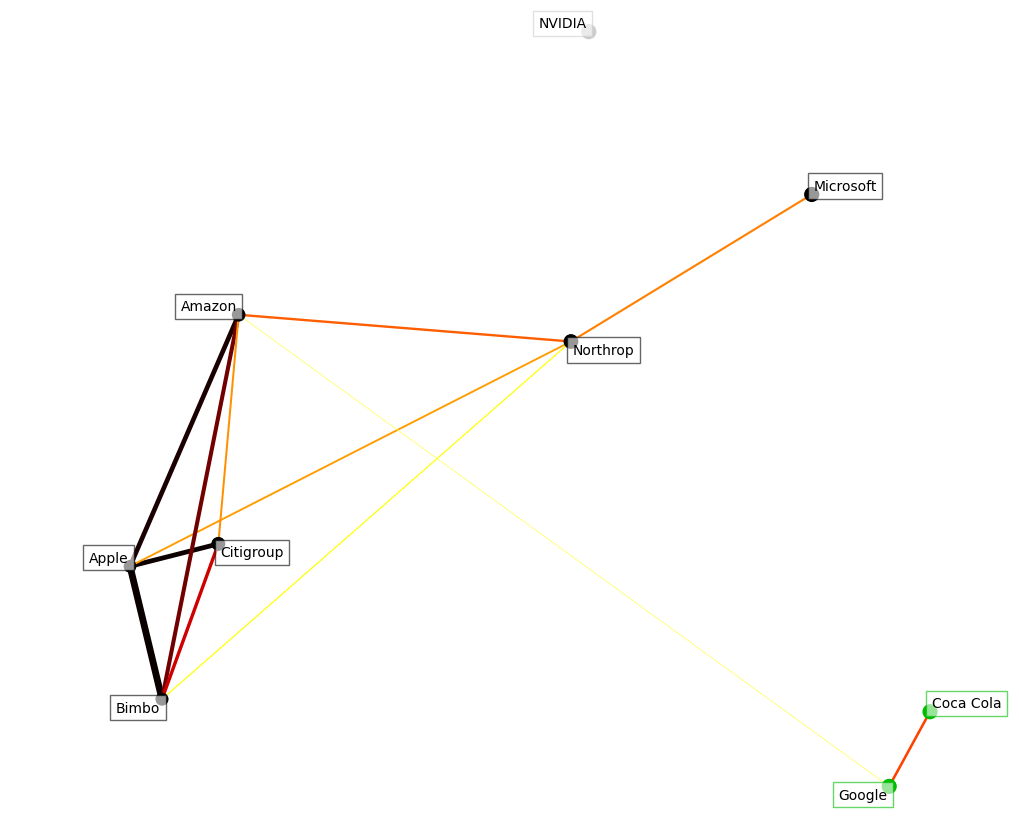

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection

plt.figure(1, facecolor="w", figsize=(10, 8))
plt.clf()
ax = plt.axes([0.0, 0.0, 1.0, 1.0])
plt.axis("off")

# Plot the graph of partial correlations
partial_correlations = edge_model.precision_.copy()
d = 1 / np.sqrt(np.diag(partial_correlations))
partial_correlations *= d
partial_correlations *= d[:, np.newaxis]
non_zero = np.abs(np.triu(partial_correlations, k=1)) > 0.02

# Plot the nodes using the coordinates of our embedding
plt.scatter(
    embedding[0], embedding[1], s=100 * d**2, c=labels, cmap=plt.cm.nipy_spectral
)

# Plot the edges
start_idx, end_idx = non_zero.nonzero()
# a sequence of (*line0*, *line1*, *line2*), where::
#            linen = (x0, y0), (x1, y1), ... (xm, ym)
segments = [
    [embedding[:, start], embedding[:, stop]] for start, stop in zip(start_idx, end_idx)
]
values = np.abs(partial_correlations[non_zero])
lc = LineCollection(
    segments, zorder=0, cmap=plt.cm.hot_r, norm=plt.Normalize(0, 0.7 * values.max())
)
lc.set_array(values)
lc.set_linewidths(15 * values)
ax.add_collection(lc)

# Add a label to each node. The challenge here is that we want to
# position the labels to avoid overlap with other labels
for index, (name, label, (x, y)) in enumerate(zip(names, labels, embedding.T)):
    dx = x - embedding[0]
    dx[index] = 1
    dy = y - embedding[1]
    dy[index] = 1
    this_dx = dx[np.argmin(np.abs(dy))]
    this_dy = dy[np.argmin(np.abs(dx))]
    if this_dx > 0:
        horizontalalignment = "left"
        x = x + 0.002
    else:
        horizontalalignment = "right"
        x = x - 0.002
    if this_dy > 0:
        verticalalignment = "bottom"
        y = y + 0.002
    else:
        verticalalignment = "top"
        y = y - 0.002
    plt.text(
        x,
        y,
        name,
        size=10,
        horizontalalignment=horizontalalignment,
        verticalalignment=verticalalignment,
        bbox=dict(
            facecolor="w",
            edgecolor=plt.cm.nipy_spectral(label / float(n_labels)),
            alpha=0.6,
        ),
    )

plt.xlim(
    embedding[0].min() - 0.15 * np.ptp(embedding[0]),
    embedding[0].max() + 0.10 * np.ptp(embedding[0]),
)
plt.ylim(
    embedding[1].min() - 0.03 * np.ptp(embedding[1]),
    embedding[1].max() + 0.03 * np.ptp(embedding[1]),
)

plt.show()